# 📊 Análise Exploratória de Dados (EDA)
Dataset: students_performance.csv

## 1. Importação de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style="whitegrid")

## 2. Carregamento dos Dados

In [2]:
df = pd.read_csv('../../data/datasets/students_performance.csv')
df.head()

,student_id,age,gender,parental_education,study_hours_week,attendance_rate,extracurricular,sleep_hours,previous_scores,tutoring,internet_quality,family_income,health_status,final_grade
0,STD01416,22,M,bachelor,5.66,69.55,Yes,6.49,49.41,No,Good,Medium,Good,85.39
1,STD01345,19,M,bachelor,13.30,58.82,Yes,8.12,50.29,No,NaN,Medium,Good,98.43
2,STD01705,25,M,master,10.43,59.72,Yes,6.60,71.64,No,Good,Medium,Good,100.00
3,STD00299,21,F,bachelor,3.90,68.33,Yes,6.99,50.93,Yes,Poor,Low,Excellent,86.85
4,STD01762,19,F,bachelor,4.24,50.44,Yes,8.06,54.00,No,Poor,Medium,Excellent,83.25


In [3]:
df.shape

(2510, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2510 entries, 0 to 2509
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          2510 non-null   object 
 1   age                 2510 non-null   int64  
 2   gender              2510 non-null   object 
 3   parental_education  2510 non-null   object 
 4   study_hours_week    2217 non-null   float64
 5   attendance_rate     2278 non-null   float64
 6   extracurricular     2510 non-null   object 
 7   sleep_hours         2244 non-null   float64
 8   previous_scores     2383 non-null   float64
 9   tutoring            2510 non-null   object 
 10  internet_quality    2355 non-null   object 
 11  family_income       2232 non-null   object 
 12  health_status       2510 non-null   object 
 13  final_grade         2510 non-null   float64
dtypes: float64(5), int64(1), object(8)
memory usage: 274.7+ KB


In [5]:
df.describe()

,age,study_hours_week,attendance_rate,sleep_hours,previous_scores,final_grade
count,2510.000000,2217.000000,2278.000000,2244.000000,2383.000000,2510.000000
mean,21.623904,10.603554,59.679789,6.996569,57.261028,92.090076
std,2.766664,8.635456,10.611523,1.336190,9.477943,7.446434
min,17.000000,-3.620000,20.820000,2.070000,21.200000,63.240000
25%,20.000000,6.510000,52.840000,6.130000,51.105000,86.982500
50%,22.000000,9.960000,59.905000,6.990000,57.300000,93.310000
75%,24.000000,13.400000,66.652500,7.830000,63.620000,99.850000
max,99.000000,113.200000,108.950000,15.950000,86.100000,101.070000


## 3. Visão Geral do Dataset

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns
numeric_cols, categorical_cols

(Index(['age', 'study_hours_week', 'attendance_rate', 'sleep_hours',
        'previous_scores', 'final_grade'],
       dtype='object'),
 Index(['student_id', 'gender', 'parental_education', 'extracurricular',
        'tutoring', 'internet_quality', 'family_income', 'health_status'],
       dtype='object'))

## 4. Análise de Valores Faltantes

In [7]:
missing = df.isna().sum()
missing_percent = (missing/len(df))*100
missing_df = pd.DataFrame({'missing': missing, 'percent': missing_percent})
missing_df

,missing,percent
student_id,0,0.000000
age,0,0.000000
gender,0,0.000000
parental_education,0,0.000000
study_hours_week,293,11.673307
attendance_rate,232,9.243028
extracurricular,0,0.000000
sleep_hours,266,10.597610
previous_scores,127,5.059761
tutoring,0,0.000000


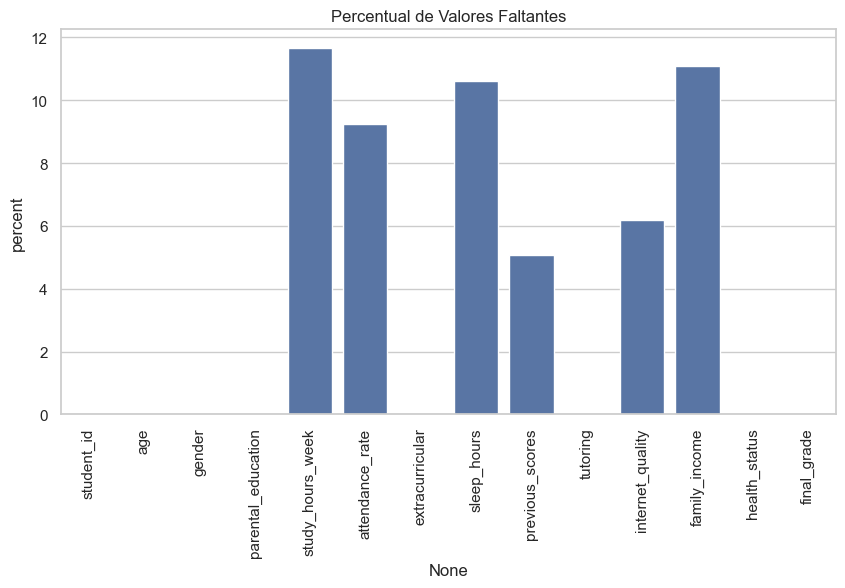

In [8]:
plt.figure(figsize=(10,5))
sns.barplot(x=missing_df.index, y='percent', data=missing_df)
plt.xticks(rotation=90)
plt.title('Percentual de Valores Faltantes')
plt.show()

## 5. Análise da Variável Alvo: final_grade

In [9]:
df['final_grade'].describe()

count    2510.000000
mean       92.090076
std         7.446434
min        63.240000
25%        86.982500
50%        93.310000
75%        99.850000
max       101.070000
Name: final_grade, dtype: float64

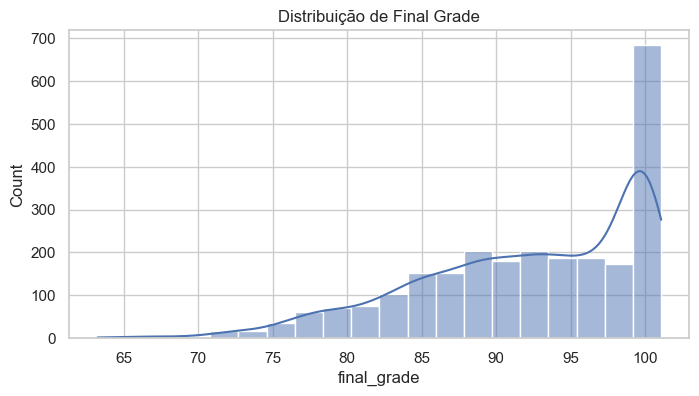

In [10]:
plt.figure(figsize=(8,4))
sns.histplot(df['final_grade'], kde=True)
plt.title('Distribuição de Final Grade')
plt.show()

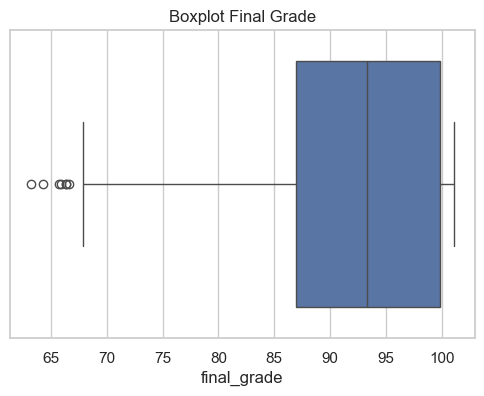

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['final_grade'])
plt.title('Boxplot Final Grade')
plt.show()

In [12]:
stats.shapiro(df['final_grade'].dropna())

ShapiroResult(statistic=np.float64(0.9029095756313555), pvalue=np.float64(2.910521361491983e-37))

## 6. Análise Univariada - Variáveis Numéricas

--- age ---


count    2510.000000
mean       21.623904
std         2.766664
min        17.000000
25%        20.000000
50%        22.000000
75%        24.000000
max        99.000000
Name: age, dtype: float64

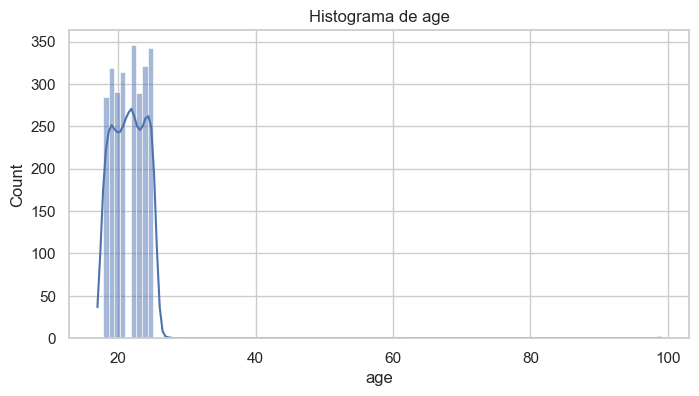

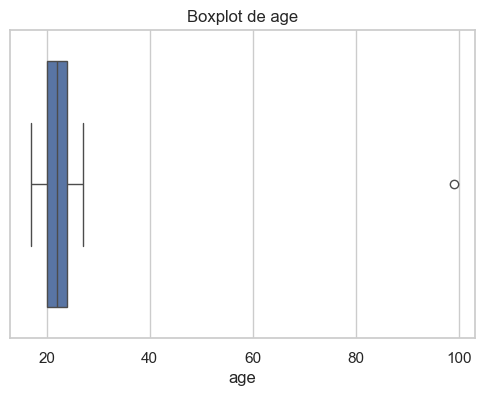

Outliers: 1
--- study_hours_week ---


count    2217.000000
mean       10.603554
std         8.635456
min        -3.620000
25%         6.510000
50%         9.960000
75%        13.400000
max       113.200000
Name: study_hours_week, dtype: float64

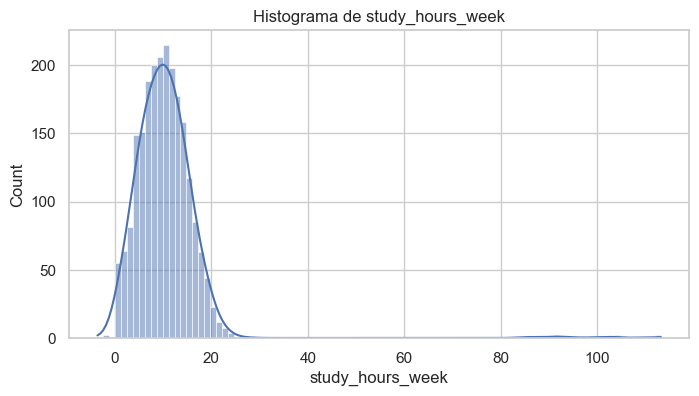

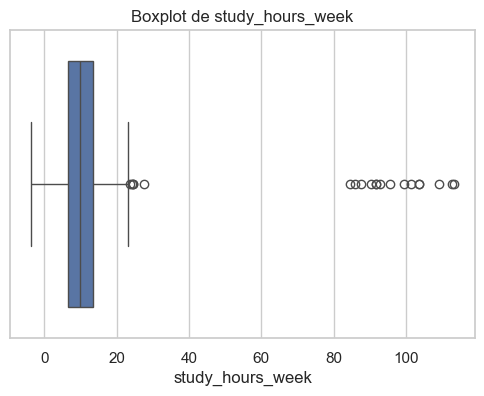

Outliers: 20
--- attendance_rate ---


count    2278.000000
mean       59.679789
std        10.611523
min        20.820000
25%        52.840000
50%        59.905000
75%        66.652500
max       108.950000
Name: attendance_rate, dtype: float64

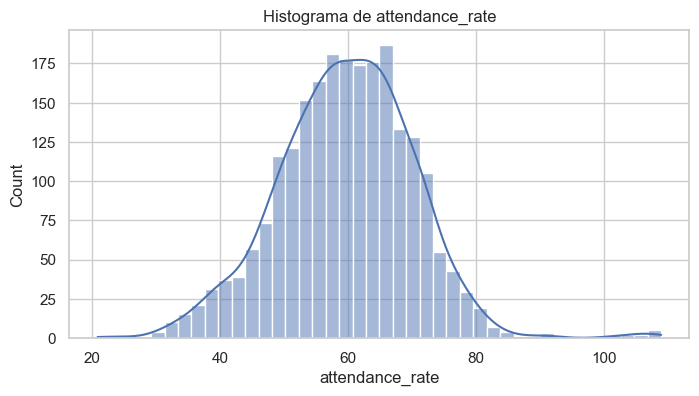

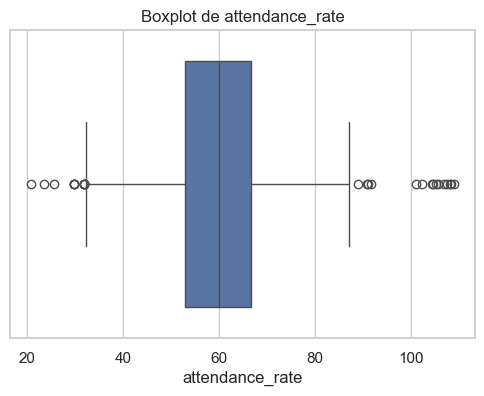

Outliers: 27
--- sleep_hours ---


count    2244.000000
mean        6.996569
std         1.336190
min         2.070000
25%         6.130000
50%         6.990000
75%         7.830000
max        15.950000
Name: sleep_hours, dtype: float64

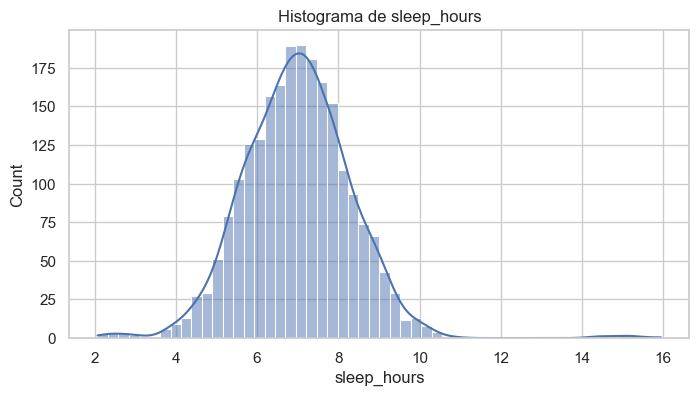

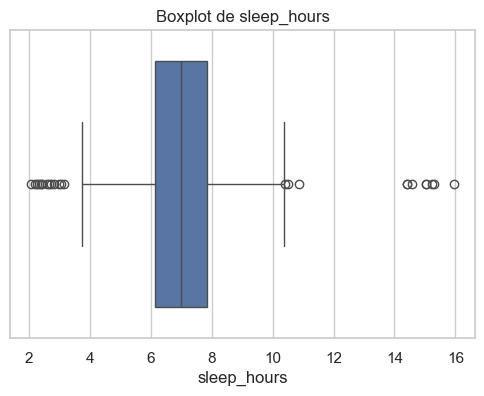

Outliers: 24
--- previous_scores ---


count    2383.000000
mean       57.261028
std         9.477943
min        21.200000
25%        51.105000
50%        57.300000
75%        63.620000
max        86.100000
Name: previous_scores, dtype: float64

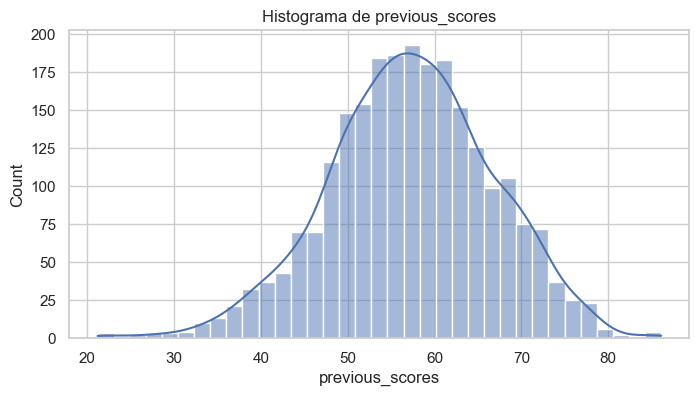

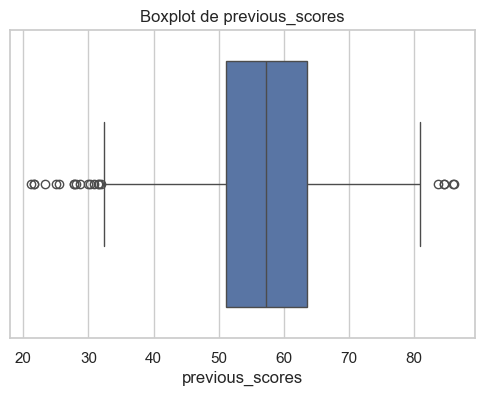

Outliers: 21


In [13]:
for col in numeric_cols:
    if col in ['student_id','final_grade']:
        continue
    print('---', col, '---')
    display(df[col].describe())

    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Histograma de {col}')
    plt.show()

    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
    plt.show()

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1
    outliers = df[(df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)]
    print('Outliers:', len(outliers))

## 7. Análise Univariada - Variáveis Categóricas

--- student_id ---
student_id
STD01416    1
STD01345    1
STD01705    1
STD00299    1
STD01762    1
           ..
STD00680    1
STD01401    1
STD02028    1
STD01147    1
STD00501    1
Name: count, Length: 2510, dtype: int64
student_id
STD01416    0.039841
STD01345    0.039841
STD01705    0.039841
STD00299    0.039841
STD01762    0.039841
              ...   
STD00680    0.039841
STD01401    0.039841
STD02028    0.039841
STD01147    0.039841
STD00501    0.039841
Name: proportion, Length: 2510, dtype: float64


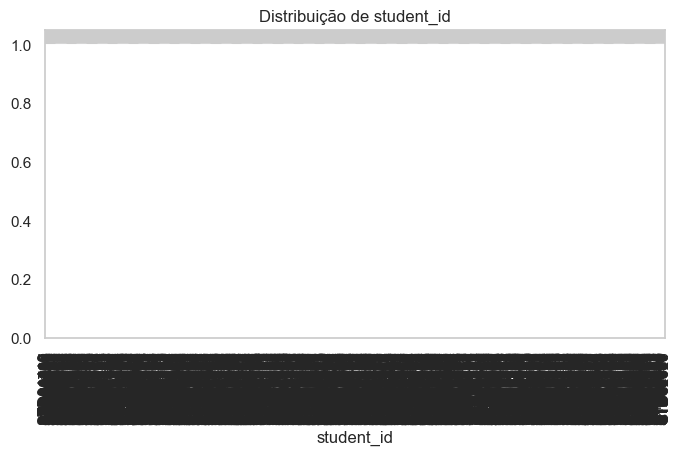

--- gender ---
gender
F          1298
M          1190
  M          10
  F           8
Female        2
Male          1
    M         1
Name: count, dtype: int64
gender
F          51.713147
M          47.410359
  M         0.398406
  F         0.318725
Female      0.079681
Male        0.039841
    M       0.039841
Name: proportion, dtype: float64


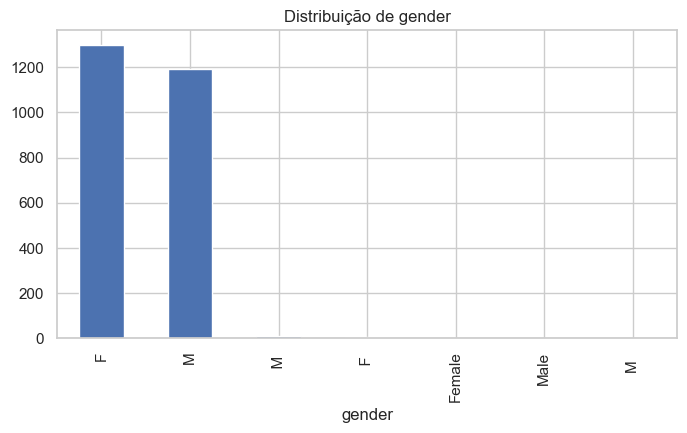

--- parental_education ---
parental_education
bachelor          1009
high_school        810
master             481
doctorate          175
  bachelor          11
BACHELOR             7
  high_school        5
HIGH_SCHOOL          4
MASTER               3
  doctorate          3
DOCTORATE            1
  master             1
Name: count, dtype: int64
parental_education
bachelor          40.199203
high_school       32.270916
master            19.163347
doctorate          6.972112
  bachelor         0.438247
BACHELOR           0.278884
  high_school      0.199203
HIGH_SCHOOL        0.159363
MASTER             0.119522
  doctorate        0.119522
DOCTORATE          0.039841
  master           0.039841
Name: proportion, dtype: float64


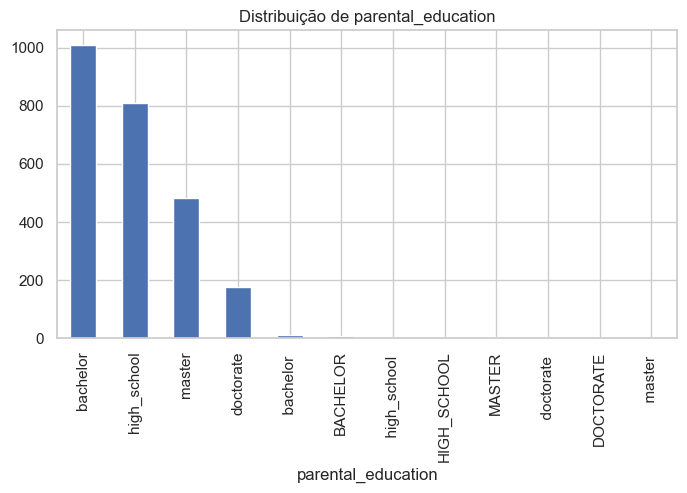

--- extracurricular ---
extracurricular
Yes       1498
No         977
  Yes       13
YES         12
  No         7
NO           3
Name: count, dtype: int64
extracurricular
Yes       59.681275
No        38.924303
  Yes      0.517928
YES        0.478088
  No       0.278884
NO         0.119522
Name: proportion, dtype: float64


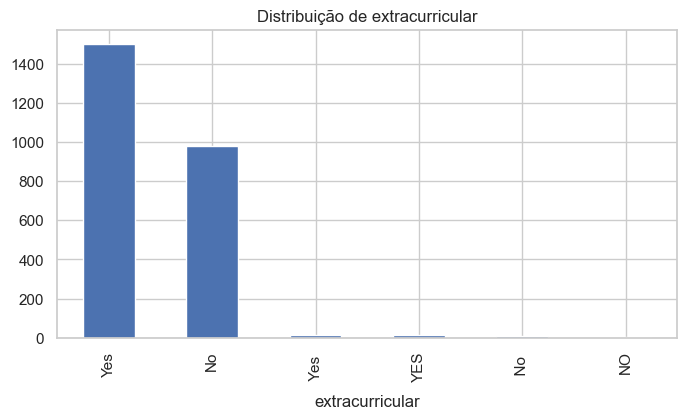

--- tutoring ---
tutoring
No        1617
Yes        858
  No        11
YES          9
  Yes        9
NO           6
Name: count, dtype: int64
tutoring
No        64.422311
Yes       34.183267
  No       0.438247
YES        0.358566
  Yes      0.358566
NO         0.239044
Name: proportion, dtype: float64


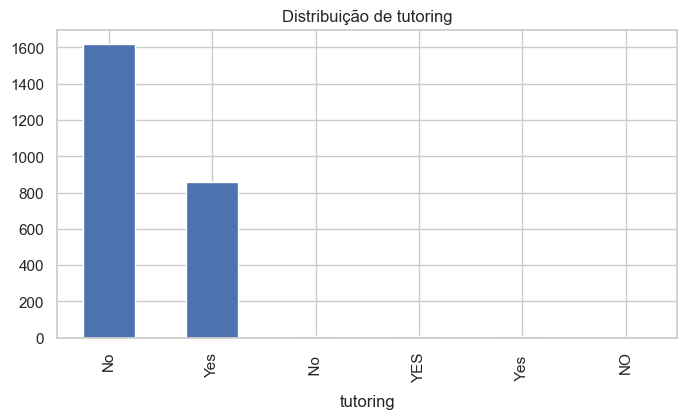

--- internet_quality ---
internet_quality
Good            1161
Excellent        812
Poor             348
  Good            11
GOOD               8
  Excellent        7
POOR               4
EXCELLENT          3
  Poor             1
Name: count, dtype: int64
internet_quality
Good            49.299363
Excellent       34.479830
Poor            14.777070
  Good           0.467091
GOOD             0.339703
  Excellent      0.297240
POOR             0.169851
EXCELLENT        0.127389
  Poor           0.042463
Name: proportion, dtype: float64


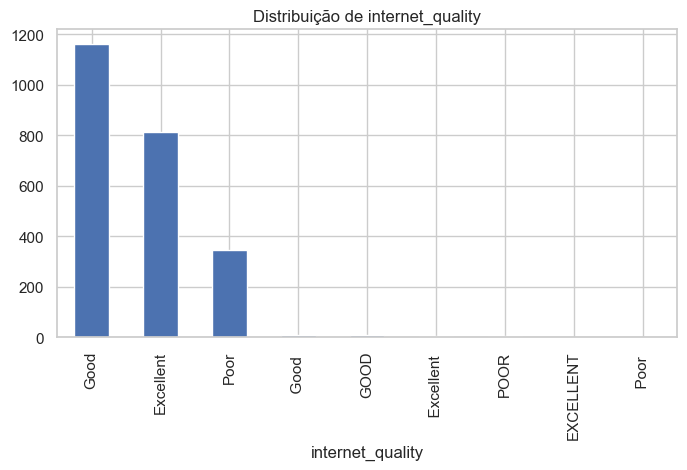

--- family_income ---
family_income
Medium       1094
Low           703
High          406
  Medium        8
LOW             6
  Low           6
MEDIUM          5
HIGH            2
  High          2
Name: count, dtype: int64
family_income
Medium       49.014337
Low          31.496416
High         18.189964
  Medium      0.358423
LOW           0.268817
  Low         0.268817
MEDIUM        0.224014
HIGH          0.089606
  High        0.089606
Name: proportion, dtype: float64


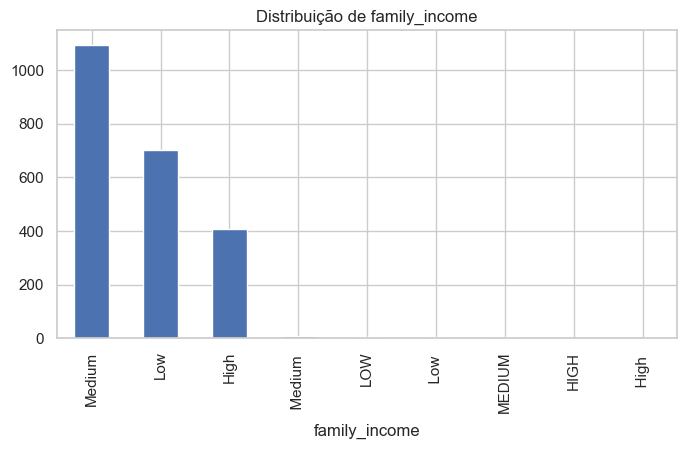

--- health_status ---
health_status
Good            1438
Excellent        765
Poor             272
  Good            12
EXCELLENT          9
  Excellent        6
GOOD               4
POOR               2
  Poor             2
Name: count, dtype: int64
health_status
Good            57.290837
Excellent       30.478088
Poor            10.836653
  Good           0.478088
EXCELLENT        0.358566
  Excellent      0.239044
GOOD             0.159363
POOR             0.079681
  Poor           0.079681
Name: proportion, dtype: float64


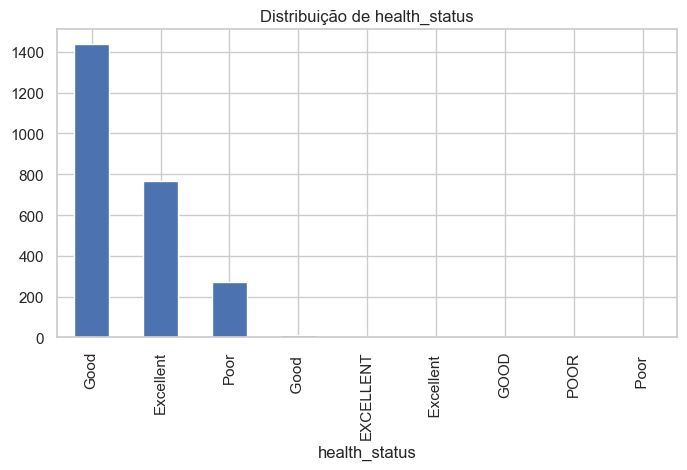

In [14]:
for col in categorical_cols:
    print('---', col, '---')
    print(df[col].value_counts())
    print(df[col].value_counts(normalize=True)*100)

    plt.figure(figsize=(8,4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Distribuição de {col}')
    plt.show()

## 8. Análise de Correlações

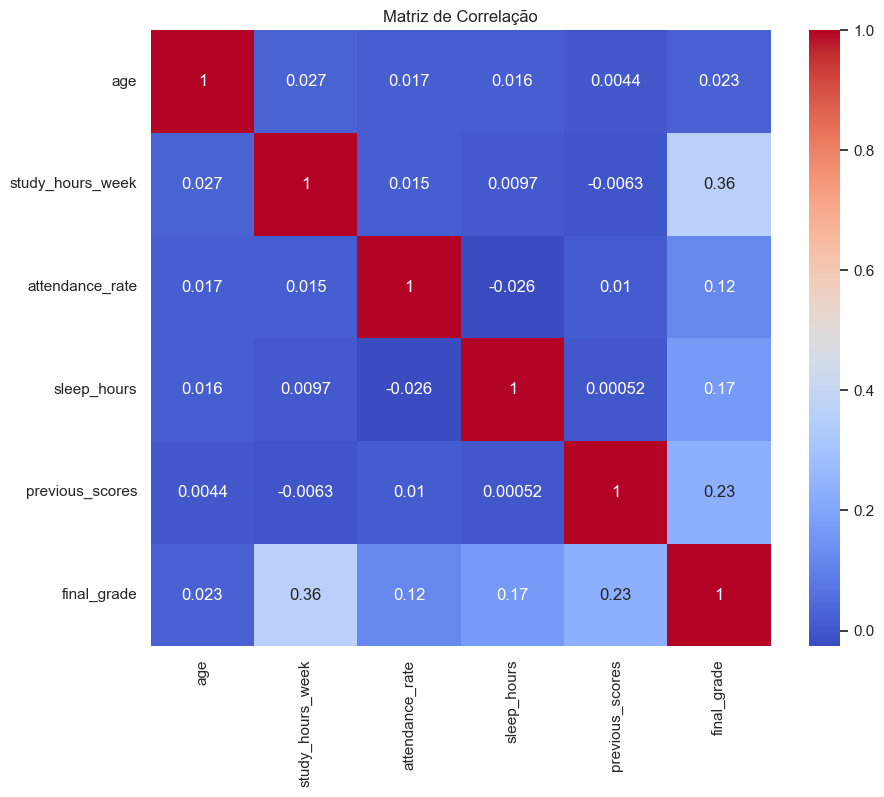

In [15]:
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação')
plt.show()

In [16]:
df[numeric_cols].corr()['final_grade'].sort_values(ascending=False)

final_grade         1.000000
study_hours_week    0.362867
previous_scores     0.226769
sleep_hours         0.167616
attendance_rate     0.117923
age                 0.023194
Name: final_grade, dtype: float64

## 9. Análise Bivariada

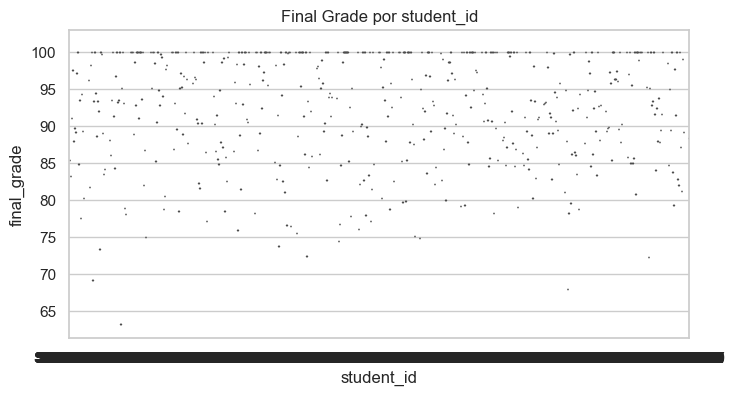

student_id
STD00001     98.51
STD00002     95.11
STD00003     91.70
STD00004     89.67
STD00005     75.28
             ...  
STD02506     91.37
STD02507     96.63
STD02508     93.24
STD02509     88.89
STD02510    101.07
Name: final_grade, Length: 2510, dtype: float64


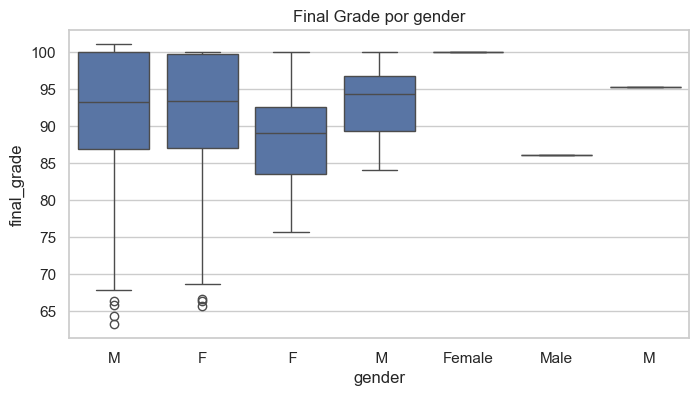

gender
    M       95.270000
  F         88.248750
  M         93.405000
F           92.098112
Female     100.000000
M           92.085185
Male        86.060000
Name: final_grade, dtype: float64


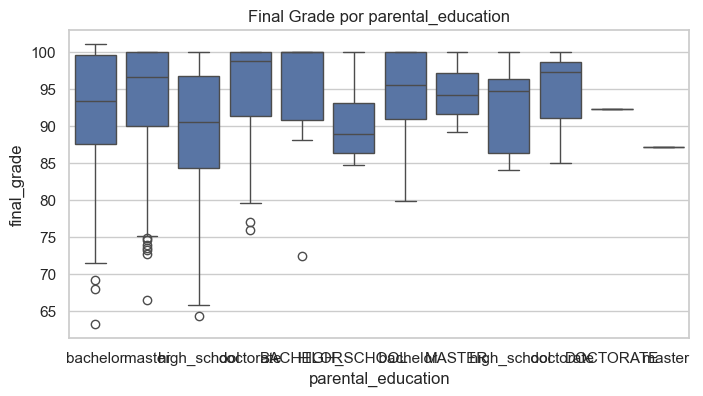

parental_education
  bachelor        94.218182
  doctorate       94.060000
  high_school     92.262000
  master          87.080000
BACHELOR          93.421429
DOCTORATE         92.250000
HIGH_SCHOOL       90.587500
MASTER            94.420000
bachelor          92.332131
doctorate         95.386171
high_school       89.837519
master            94.102328
Name: final_grade, dtype: float64


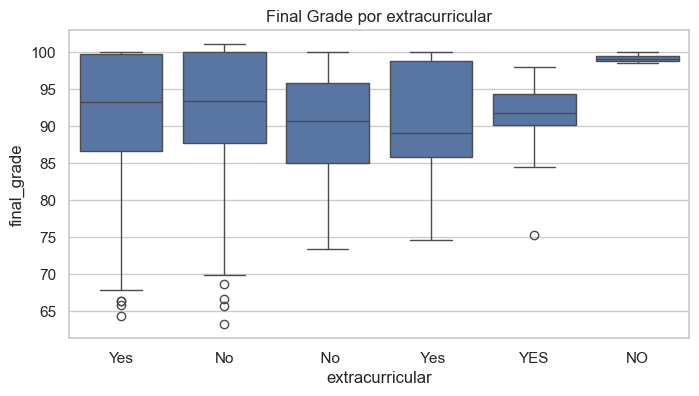

extracurricular
  No      89.410000
  Yes     90.649231
NO        99.203333
No        92.416407
YES       90.921667
Yes       91.897383
Name: final_grade, dtype: float64


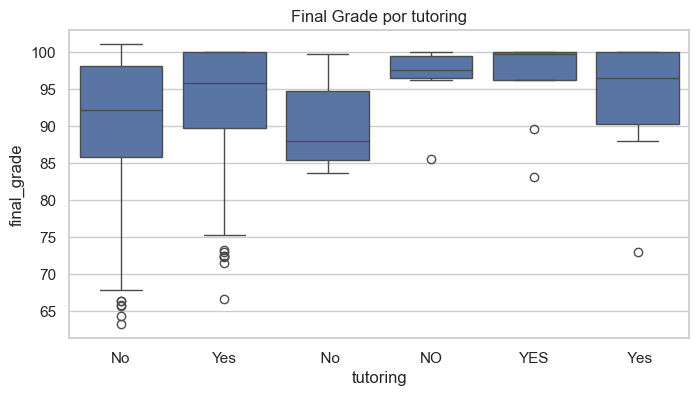

tutoring
  No      90.243636
  Yes     93.066667
NO        96.176667
No        91.059852
YES       96.137778
Yes       93.974044
Name: final_grade, dtype: float64


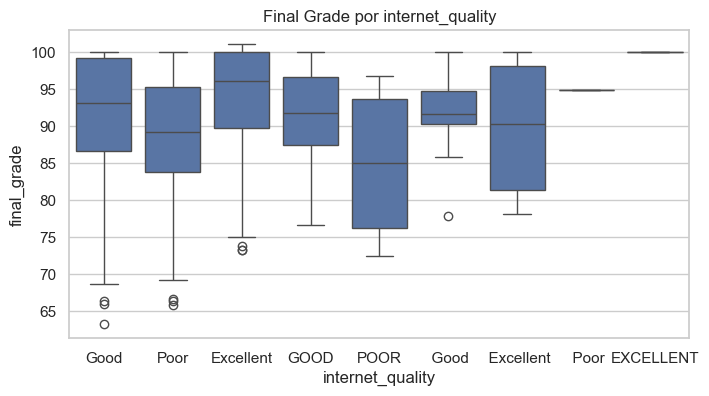

internet_quality
  Excellent      89.627143
  Good           91.737273
  Poor           94.820000
EXCELLENT       100.000000
Excellent        94.028645
GOOD             90.671250
Good             91.790241
POOR             84.822500
Poor             88.942270
Name: final_grade, dtype: float64


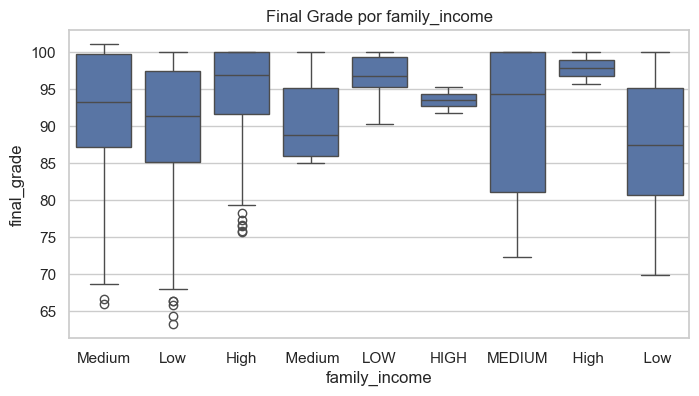

family_income
  High       97.865000
  Low        86.801667
  Medium     90.717500
HIGH         93.500000
High         94.989828
LOW          96.476667
Low          90.466415
MEDIUM       89.530000
Medium       92.113821
Name: final_grade, dtype: float64


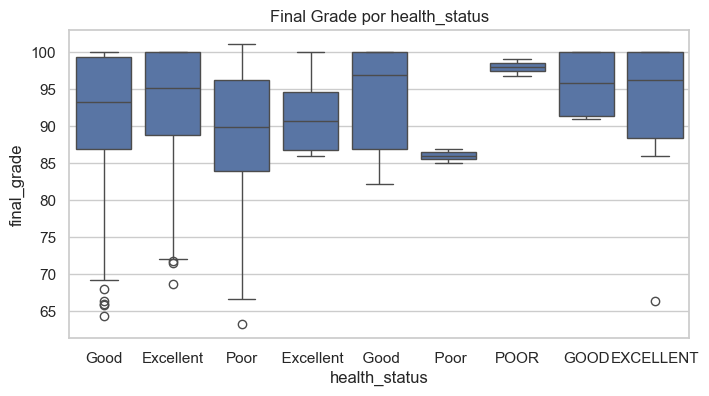

health_status
  Excellent     91.451667
  Good          93.247500
  Poor          85.960000
EXCELLENT       92.217778
Excellent       93.420588
GOOD            95.610000
Good            91.956099
POOR            97.935000
Poor            88.965441
Name: final_grade, dtype: float64


In [17]:
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col], y=df['final_grade'])
    plt.title(f'Final Grade por {col}')
    plt.show()

    print(df.groupby(col)['final_grade'].mean())

## 10. Identificação de Outliers

In [18]:
outlier_summary={}
for col in numeric_cols:
    if col=='student_id': continue
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    outliers=df[(df[col]<Q1-1.5*IQR)|(df[col]>Q3+1.5*IQR)]
    outlier_summary[col]=len(outliers)
outlier_summary

{'age': 1,
 'study_hours_week': 20,
 'attendance_rate': 27,
 'sleep_hours': 24,
 'previous_scores': 21,
 'final_grade': 7}

## 11. Conclusões e Descobertas
A análise exploratória mostrou que o dataset possui 2.510 registros e boa qualidade geral, com poucas variáveis apresentando valores faltantes, sendo internet_quality a principal delas. Algumas variáveis numéricas exibiram outliers, mas a maioria parece representar casos reais. A distribuição de final_grade é levemente assimétrica, com a maior parte das notas entre 70 e 90 pontos. As variáveis que mais se relacionam com a nota final são previous_scores, study_hours_week e attendance_rate, indicando que histórico acadêmico, tempo de estudo e presença influenciam fortemente o desempenho. Já gênero, renda, educação dos pais e qualidade da internet mostraram pouca correlação. A análise bivariada também revelou que alunos com tutoria, boas rotinas de estudo ou saúde melhor tendem a ter notas mais altas. Esses achados ajudam a orientar a próxima fase do projeto, que incluirá tratamento de missing, padronização e preparação das variáveis para modelagem.